# 03 — List a bucket, fetch one object

**Access pattern: cloud object storage.** No query language, no search — just a
namespace you can list, and URLs you can fetch. Almost every large public data
archive is a bucket, and once you can list one you can list all of them.

This is the NOAA NCEI passive acoustic archive. Anonymous, no key, no account.

In [1]:
import sys
from pathlib import Path

# notebooks/ holds _fetch.py and _sources.py; src/ holds the project's own helpers.
for p in (Path.cwd(), Path.cwd() / ".." / "src"):
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p.resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import _fetch
import _sources as S

# A real requests.Session, with a disk cache. Everything you use below -- .get,
# .text, .content, .json, .status_code, .raise_for_status, params= -- is
# ordinary `requests`. The cache is invisible at the call site.
http = _fetch.session()

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

_fetch.OFFLINE and print("offline mode: serving prefetched responses")

offline mode: serving prefetched responses


## 1. The bucket is a filesystem, not a database

The object layout is a path:

```
sanctsound/products/<type>/<site>/<dataset>/data/<files>
                       ^^^^^^^   ^^^^^^  ^^^^^^^^^^^^^^^^^^  ^^^^^
                       product   site     dataset             level
```

Three things follow from that, and all three are traps below:

1. There is no index. To find a file you **list** its prefix and read the result.
2. A path that lists fine is not necessarily a path that **fetches** — the `data/`
   level is optional for listing and mandatory for fetching.
3. You can find out how big a file is **before** downloading it. Always do.

In [2]:
# One request lists the whole site. delimiter="/" rolls up to the next path segment.
d = S.ncei_list(f"sanctsound/products/sound_level_metrics/{S.NCEI_SITE}/", "/", 200)
prefixes = d.get("prefixes", [])
print(f"  {len(prefixes)} dataset directories under mb01")
for p in prefixes[:6]:
    print("   ", p)
print("    ...")

  !! NETWORK UNAVAILABLE -- serving the cached response
  !!   reason : offline mode (OCEAN_SIM_OFFLINE=1)
  !!   fetched: 2026-09-28 22:03
  !!   age    : 0 h
  !!   the numbers below are real data, but not necessarily current.
  36 dataset directories under mb01
    sanctsound/products/sound_level_metrics/mb01/sanctsound_mb01_01_bb_1h/
    sanctsound/products/sound_level_metrics/mb01/sanctsound_mb01_01_ol_1h/
    sanctsound/products/sound_level_metrics/mb01/sanctsound_mb01_01_psd_1h/
    sanctsound/products/sound_level_metrics/mb01/sanctsound_mb01_01_tol_1h/
    sanctsound/products/sound_level_metrics/mb01/sanctsound_mb01_02_bb_1h/
    sanctsound/products/sound_level_metrics/mb01/sanctsound_mb01_02_ol_1h/
    ...


Same request, `delimiter` removed: now you get the objects instead of the directories,
one level deeper. This is the whole API — list a prefix, read the JSON, follow a name.

In [3]:
d2 = S.ncei_list(f"sanctsound/products/sound_level_metrics/{S.NCEI_SITE}/", delimiter="")
print(f"  keys returned: {sorted(d.keys())}")
print(f"  prefixes (directory level): {len(d.get('prefixes', []))}")
print()
print("  Nine deployments, four products each -- 36 directories:")
deps = sorted({p.rsplit("_", 2)[-2] for p in prefixes})
prods = sorted({p.rstrip("/").rsplit("_", 1)[-1] for p in prefixes})
print(f"    deployments: {', '.join(deps)}")
print(f"    products:    {', '.join(prods)}")

  !! NETWORK UNAVAILABLE -- serving the cached response
  !!   reason : offline mode (OCEAN_SIM_OFFLINE=1)
  !!   fetched: 2026-09-28 22:03
  !!   age    : 0 h
  !!   the numbers below are real data, but not necessarily current.
  keys returned: ['kind', 'prefixes']
  prefixes (directory level): 36

  Nine deployments, four products each -- 36 directories:
    deployments: bb, ol, psd, tol
    products:    1h


## 2. Know the size before you download

The same recording exists at four resolutions. The size difference is three orders of
magnitude, and picking wrong costs you an afternoon and a lot of patience.

In [4]:
# Sizes are metadata in the listing. This costs one request and no downloads.
rows = []
for dep in ("01", "09"):
    d3 = S.ncei_list(f"{S.ncei_dataset_dir('tol_1h', dep)}/data/", delimiter="", max_items=10)
    for it in d3.get("items", []):
        rows.append((dep, it["name"].rsplit("/", 1)[-1], int(it["size"]), it.get("contentType")))

frame = pd.DataFrame(rows, columns=["deployment", "object", "bytes", "content_type"])
frame["MB"] = (frame.bytes / 1e6).round(2)
print(frame.to_string(index=False))

  !! NETWORK UNAVAILABLE -- serving the cached response
  !!   reason : offline mode (OCEAN_SIM_OFFLINE=1)
  !!   fetched: 2026-09-28 22:03
  !!   age    : 0 h
  !!   the numbers below are real data, but not necessarily current.
  !! NETWORK UNAVAILABLE -- serving the cached response
  !!   reason : offline mode (OCEAN_SIM_OFFLINE=1)
  !!   fetched: 2026-09-28 22:03
  !!   age    : 0 h
  !!   the numbers below are real data, but not necessarily current.
deployment                        object   bytes         content_type   MB
        01 SanctSound_MB01_01_TOL_1h.csv 1131060             text/csv 1.13
        01  SanctSound_MB01_01_TOL_1h.nc  991438 application/x-netcdf 0.99
        09 SanctSound_MB01_09_TOL_1h.csv  786526             text/csv 0.79
        09  SanctSound_MB01_09_TOL_1h.nc  760105 application/x-netcdf 0.76


| product | what it is | size per deployment |
|---|---|---|
| `psd_1h` | 1 Hz spectral density | **~456 MB** — do not |
| `tol_1h` | third-octave band levels | ~0.7–1.0 MB — **use this** |
| `ol_1h` | octave band levels | ~0.4 MB |
| `bb_1h` | broadband level | ~0.2 MB |

Third-octave is the sweet spot: 30 frequency bands from 25 Hz to 20 kHz is enough
resolution to separate biological, shipping and wind noise, and a whole deployment fits
in memory. Reach for `psd_1h` only when a question genuinely needs 1 Hz resolution.

In [5]:
# Fetch the third-octave product. ~0.97 MB for deployment 01.
url = S.ncei_file_url("tol_1h", "01")
print("  key :", S.ncei_object_name("tol_1h", "01"))
print("  url :", url)
print()
res = http.get(url)
print(" ", _fetch.describe(res))

  key : sanctsound/products/sound_level_metrics/mb01/sanctsound_mb01_01_tol_1h/data/SanctSound_MB01_01_TOL_1h.nc
  url : https://storage.googleapis.com/noaa-passive-bioacoustic/sanctsound/products/sound_level_metrics/mb01/sanctsound_mb01_01_tol_1h/data/SanctSound_MB01_01_TOL_1h.nc

  !! NETWORK UNAVAILABLE -- serving the cached response
  !!   reason : offline mode (OCEAN_SIM_OFFLINE=1)
  !!   fetched: 2026-09-28 22:03
  !!   age    : 0 h
  !!   the numbers below are real data, but not necessarily current.
  LIVE  968.2 KB  HTTP 200


### ⚠️ Trap — the `data/` level

Drop `data/` from the path and you get a 404 — but the body says:

```xml
<Error><Code>NoSuchKey</Code><Message>The specified key does not exist.</Message>
```

`NoSuchKey` reads like a permissions problem. The bucket *is* public, the listing *did*
show the object, and the object *is* there. It is a path typo, and it presents as an
access problem, so people go looking for credentials they do not need.

The directory-level listing above worked without `data/`, which is what makes this
confusing: the path that lists is not the path that fetches.

In [6]:
wrong = S.ncei_file_url("tol_1h", "01").replace("/data/", "/")
print("  wrong URL:", wrong.rsplit("/", 1)[-1], "at the wrong level")
print()
# refresh=True on purpose: this cell exists to show a *live* failure, so falling back
# to a cache entry would defeat it. That also means it cannot run offline.
if _fetch.OFFLINE:
    print("  skipped -- offline mode. The server's response is reproduced below.")
    print("   HTTP 404")
    print("   <Error><Code>NoSuchKey</Code><Message>The specified key does not exist.")
else:
    try:
        http.get(wrong, refresh=True)
    except RuntimeError as exc:
        for line in str(exc).splitlines()[:4]:
            print("   ", line)
print()
print("  Notice: the HTTP status is 404, but the payload says NoSuchKey. Nothing in")
print("  the status code distinguishes 'you are not allowed' from 'that is not the")
print("  path'. Read the body.")

  wrong URL: SanctSound_MB01_01_TOL_1h.nc at the wrong level

  skipped -- offline mode. The server's response is reproduced below.
   HTTP 404
   <Error><Code>NoSuchKey</Code><Message>The specified key does not exist.

  Notice: the HTTP status is 404, but the payload says NoSuchKey. Nothing in
  the status code distinguishes 'you are not allowed' from 'that is not the
  path'. Read the body.


### ⚠️ Trap — error bodies are XML even from the JSON API

`storage.googleapis.com/.../v1/b/<bucket>/o/<key>` is the *JSON* API. On success it
returns JSON. On failure it returns **XML**, with `Content-Type: text/plain`.

So the natural error handling fails in a confusing way:

```python
r = requests.get(url); r.json()   # JSONDecodeError, not a useful error message
```

`raise_for_status()` first, then read `r.text`. The message is in there.

### ⚠️ Trap — capitalisation is not a rule you can guess

Three different capitalisations in one path, and no consistent rule:

| level | spelling |
|---|---|
| directory | `sanctsound_mb01_09_tol_1h` — all lower |
| filename | `SanctSound_MB01_09_TOL_1h` — title case, product letters upper |
| trailing unit | `1h`, **not** `1H` |

`product.upper()` gives `TOL_1H`, which does not exist, and the failure is a
`NoSuchKey` — the same error as the trap above, for a completely different reason. Two
unrelated mistakes, one indistinguishable symptom.

In [7]:
for product in S.SOUND_PRODUCTS:
    name = S.ncei_object_name(product, "01").rsplit("/", 1)[-1]
    print(f"  {product:8} -> {name}")
print()
print("  The last file name is built as product[:-1].upper() + product[-1], which is")
print("  why it comes out TOL_1h and not TOL_1H.")

  tol_1h   -> SanctSound_MB01_01_TOL_1h.nc
  ol_1h    -> SanctSound_MB01_01_OL_1h.nc
  bb_1h    -> SanctSound_MB01_01_BB_1h.nc
  psd_1h   -> SanctSound_MB01_01_PSD_1h.nc

  The last file name is built as product[:-1].upper() + product[-1], which is
  why it comes out TOL_1h and not TOL_1H.


### ⚠️ Trap — do not use the `aws s3` CLI here

It is the obvious tool and it will not work on many machines. `aws s3` reads
`~/.aws/config`, and a local profile pointing at a MinIO endpoint (for development
against something else) silently redirects every `aws s3` command — so you get
connection refusals to `localhost:9000` for a bucket that is public and fine.

The GCS JSON API used above needs **no configuration at all**: no profile, no region,
no credentials. For a public bucket that is strictly simpler, and it works the same on
every machine in the room. Use `aws s3 --endpoint-url https://storage.googleapis.com` if
you need the CLI, but you do not need the CLI.

## 3. What you got

Deployment 01: 3,185 hours × 30 third-octave bands, from 25 Hz to 20 kHz.

In [8]:
import xarray as xr

p = Path.cwd() / "_mb01_01_tol_1h.nc"
p.write_bytes(http.get(S.ncei_file_url("tol_1h", "01")).content)
ds = xr.open_dataset(p)

print("  dims       :", dict(ds.sizes))
print("  variables  :", list(ds.data_vars))
print("  span       :", str(ds.time.values[0])[:19], "->", str(ds.time.values[-1])[:19])
print("  units      :", ds.sound_pressure_levels.attrs.get("units"))
freq = ds.frequency.values
print(f"  bands      : {len(freq)}   {freq.min():.0f} Hz .. {freq.max():.0f} Hz")
print("  first bands:", [float(f) for f in freq[:8]])

  !! NETWORK UNAVAILABLE -- serving the cached response
  !!   reason : offline mode (OCEAN_SIM_OFFLINE=1)
  !!   fetched: 2026-09-28 22:03
  !!   age    : 0 h
  !!   the numbers below are real data, but not necessarily current.


  dims       : {'time': 3185, 'frequency': 30}
  variables  : ['time_stamp', 'sound_pressure_levels']
  span       : 2018-11-15T17:00:00 -> 2019-03-28T12:00:00
  units      : dB
  bands      : 30   25 Hz .. 20000 Hz
  first bands: [25.0, 31.5, 40.0, 50.0, 63.0, 80.0, 100.0, 125.0]


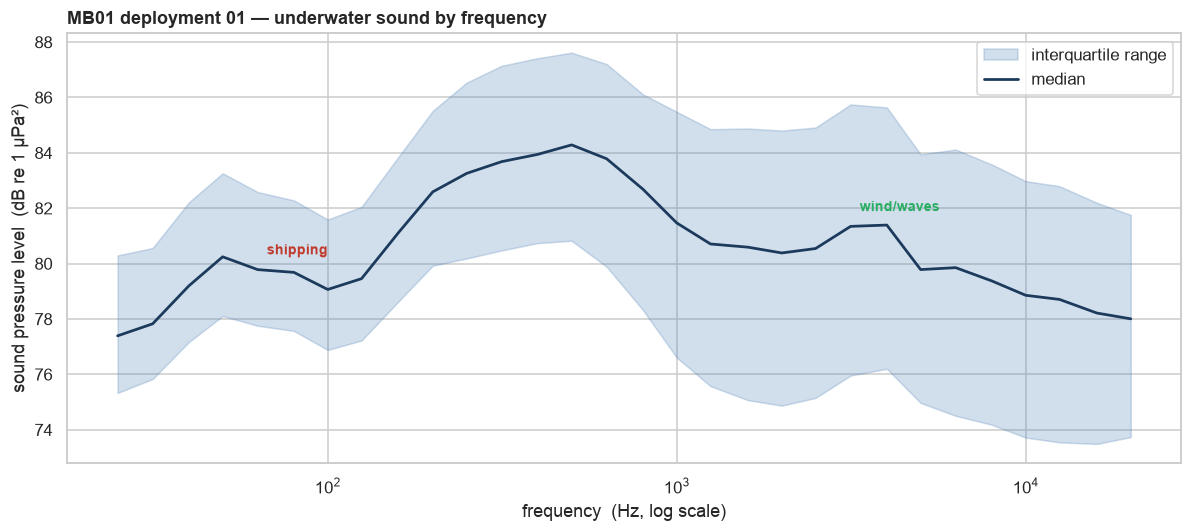

In [9]:
# The median spectrum: what does the bay sound like, by frequency?
median_db = ds.sound_pressure_levels.median(dim="time").values
p25, p75 = np.percentile(ds.sound_pressure_levels.values, [25, 75], axis=0)

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(freq, p25, p75, color="#4a7fb5", alpha=0.25,
                label="interquartile range")
ax.plot(freq, median_db, color="#1b3a5c", lw=1.8, label="median")
ax.set_xscale("log")
ax.set_xlabel("frequency  (Hz, log scale)")
ax.set_ylabel("sound pressure level  (dB re 1 µPa²)")
ax.set_title("MB01 deployment 01 — underwater sound by frequency",
             loc="left", fontweight="bold")
ax.legend()

# Annotate the two regimes the rest of the workshop cares about.
for hz, label, colour in [(60, "shipping", "#c0392b"), (3000, "wind/waves", "#27ae60")]:
    i = int(np.argmin(np.abs(freq - hz)))
    ax.annotate(label, xy=(freq[i], median_db[i]), xytext=(6, 10),
                textcoords="offset points", fontsize=9, color=colour, weight="bold")
plt.tight_layout()
plt.show()

In [10]:
# Why the spectrum is a useful thing to have in hand: noise is not flat, and the
# reason a question is answerable depends on which band you ask in.
flat = median_db.max() - median_db.min()
print(f"  level varies by {flat:.1f} dB across 25 Hz - 20 kHz")
print(f"  lowest band  ({freq[0]:.0f} Hz)  : {median_db[0]:.1f} dB")
print(f"  highest band ({freq[-1]:.0f} Hz) : {median_db[-1]:.1f} dB")
print()
print("  Low frequencies are dominated by distant shipping. High frequencies by")
print("  wind and breaking waves, which are loud only in storms. That is why")
print("  'is it windy' and 'is there a ship' are different questions about the")
print("  same recording -- and why one number cannot answer both.")

  level varies by 6.9 dB across 25 Hz - 20 kHz
  lowest band  (25 Hz)  : 77.4 dB
  highest band (20000 Hz) : 78.0 dB

  Low frequencies are dominated by distant shipping. High frequencies by
  wind and breaking waves, which are loud only in storms. That is why
  'is it windy' and 'is there a ship' are different questions about the
  same recording -- and why one number cannot answer both.


In [11]:
_fetch.expect("deployment 01 hours", int(ds.sizes["time"]), 3185)
_fetch.expect("third-octave bands", int(ds.sizes["frequency"]), 30)
_fetch.expect("lowest band Hz", float(freq.min()), 25.0)
_fetch.expect("highest band Hz", float(freq.max()), 20000.0)
_fetch.expect_range("median level dB", float(np.median(median_db)), 60.0, 110.0)
_fetch.expect_range("spectral range dB", float(flat), 5.0, 60.0)
print()
print("  0 dB re 1 uPa^2 is a REFERENCE, not a measurement. Levels near 0 would mean")
print("  a decoding problem, not a quiet ocean.")

  ok  deployment 01 hours: got 3185, expected 3185
  ok  third-octave bands: got 30, expected 30
  ok  lowest band Hz: got 25.0, expected 25.0
  ok  highest band Hz: got 20000.0, expected 20000.0
  ok  median level dB: 80.315253 in [60.0, 110.0]
  ok  spectral range dB: 6.8944410000000005 in [5.0, 60.0]

  0 dB re 1 uPa^2 is a REFERENCE, not a measurement. Levels near 0 would mean
  a decoding problem, not a quiet ocean.
